In [7]:
!d:/Crop_yield_system/.jyp_env/Scripts/python.exe -m pip install scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from analyze_src.basic_data_inspection import DataInspector,DataTypesInspectionStrategy,SummaryStatisticsInspectionStrategy
from analyze_src.missing_values_analysis import MissingValueAnalysis

pd.set_option('display.max_column',None)
pd.set_option('display.max_row',100)

   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ------ --------------------------------- 6.3/38.5 MB 31.3 MB/s eta 0:00:02
   ---------- ----------------------------- 10.0/38.5 MB 24.0 MB/s eta 0:00:02
   ------------- -------------------------- 13.4/38.5 MB 21.0 MB/s eta 0:00:02
   ------------------ --------------------- 17.6/38.5 MB 20.6 MB/s eta 0:00:02
   ----------------------- ---------------- 22.3/38.5 MB 20.7 MB/s eta 0:00:01
   --------------------------- ------------ 26.7/38.5 MB 20.8 MB/s eta 0:00:01
   -------------------------------- ------- 31.7/38.5 MB 21.2 MB/s eta 0:00:01
   ------------------------------------- -- 36.2/38.5 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------  38.3/38.5 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------- 38.5/38.5 MB 19.5 MB/s  0:00:01



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
data = pd.read_csv("D:\\Crop_yield_system\\data\\Processed\\versions\\merged_20251124_153828.csv")
data

,State,Year,Area (Hectare),Production (Tonnes),Yield (Tonne/Hectare),Season,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,RH2M,WS2M,NDVI_SeasonalMean,Mean_SOC,Median_SOC,Min_SOC,Max_SOC,Std_SOC
0,Chandigarh,2011,600,2725,4.54,Kharif,28.545820,32.636721,24.651230,1120.70,2415.25,73.597787,1.670820,0.505033,2.126695,2.000000,2.000000,6.250000,0.384204
1,Chandigarh,2011,600,2725,4.54,Rabi,18.842547,26.398585,13.192453,81.17,3551.99,46.769575,1.713396,0.383363,2.126695,2.000000,2.000000,6.250000,0.384204
2,Chandigarh,2012,575,2590,4.50,Kharif,30.871885,35.985164,26.062869,761.14,2549.54,58.650328,1.895164,0.457170,2.126695,2.000000,2.000000,6.250000,0.384204
3,Chandigarh,2012,575,2590,4.50,Rabi,18.925164,26.774977,13.223897,87.20,3528.42,41.122770,1.888967,0.380036,2.126695,2.000000,2.000000,6.250000,0.384204
4,Chandigarh,2013,575,2600,4.52,Kharif,28.820410,32.811475,24.909918,1174.10,2440.15,72.614426,1.535246,0.522958,2.126695,2.000000,2.000000,6.250000,0.384204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,Uttar Pradesh,2022,114959,114959,3.18,Rabi,20.568538,28.004623,14.275472,330.69,3359.42,61.420708,1.717264,0.484022,1.878746,1.922218,0.966074,3.644187,0.452408
2122,Uttar Pradesh,2022,79992,79992,3.14,Rabi,20.568538,28.004623,14.275472,330.69,3359.42,61.420708,1.717264,0.484022,1.878746,1.922218,0.966074,3.644187,0.452408
2123,Uttar Pradesh,2022,159816,159816,3.35,Rabi,20.568538,28.004623,14.275472,330.69,3359.42,61.420708,1.717264,0.484022,1.878746,1.922218,0.966074,3.644187,0.452408
2124,Uttar Pradesh,2023,172605,172605,3.68,Kharif,30.695820,34.808525,26.916393,785.06,2161.25,71.731311,2.367295,NaN,1.878746,1.922218,0.966074,3.644187,0.452408


In [39]:
montly_NDVI = df_NDVI[["year","month","mean"]].copy()
montly_NDVI["NDVI"] = montly_NDVI["mean"] / 10000.0

merged = pd.merge(df_weather, montly_NDVI[["year","month","NDVI"]], on=["year", "month"], how="left" )
merged["NDVI"] = merged["NDVI"].interpolate(method="linear")

merged


,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,ALLSKY_SFC_SW_DWN,RH2M,WS2M,date,year,month,NDVI
0,10.96,18.38,6.06,0.00,11.77,49.24,1.53,2020-01-01,2020,1,0.0
1,12.60,18.63,7.75,0.05,9.64,58.31,1.39,2020-01-02,2020,1,0.0
2,12.99,19.85,8.84,0.10,12.68,64.00,1.36,2020-01-03,2020,1,0.0
3,11.74,18.34,7.61,2.55,10.76,60.94,1.56,2020-01-04,2020,1,0.0
4,11.12,17.94,6.33,0.09,10.48,57.04,2.11,2020-01-05,2020,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1456,14.64,21.84,10.25,0.00,12.10,49.04,1.22,2023-12-27,2023,12,0.0
1457,14.56,22.34,10.26,0.00,7.42,47.88,1.00,2023-12-28,2023,12,0.0
1458,14.30,21.66,10.87,0.00,8.92,54.21,1.23,2023-12-29,2023,12,0.0
1459,14.72,21.13,11.06,0.00,4.46,51.05,1.14,2023-12-30,2023,12,0.0


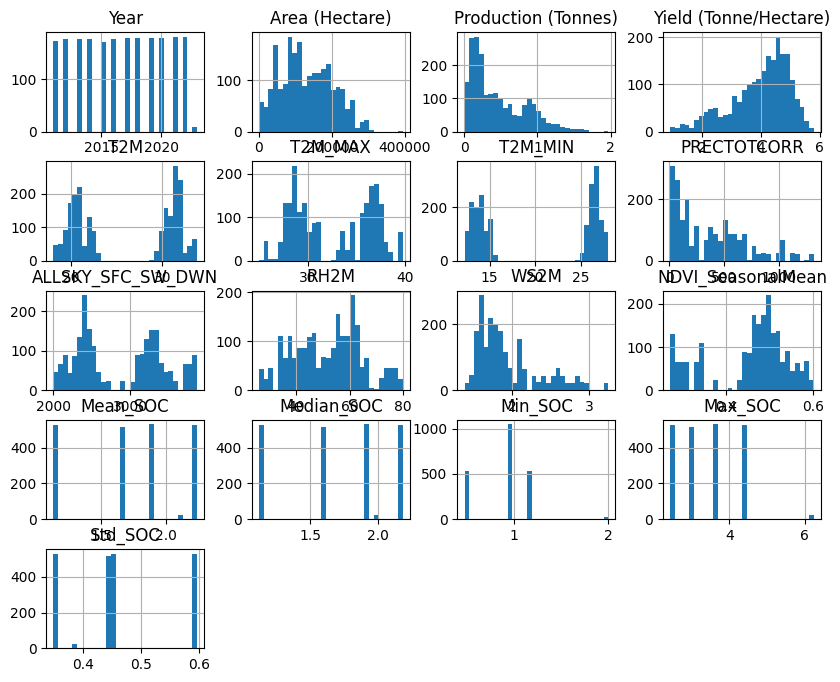

In [13]:
import matplotlib.pyplot as plt

data.hist(bins=30, figsize=(10, 8))
plt.show()


The plot shows seasonal temperature fluctuations clearly.
NDVI shows sAClight seasonal greenness increase but is much smaller in scale compared to temperature.
This suggests that temperature alone does not drive large changes in vegetation, at least for this region/time period.

In [20]:
inspector = DataInspector(DataTypesInspectionStrategy())
inspector.execute_inspection(merged)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2023-01-01 to 2023-12-01
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   T2M                365 non-null    float64
 1   T2M_MAX            365 non-null    float64
 2   T2M_MIN            365 non-null    float64
 3   PRECTOTCORR        365 non-null    float64
 4   ALLSKY_SFC_SW_DWN  365 non-null    float64
 5   RH2M               365 non-null    float64
 6   WS2M               365 non-null    float64
 7   year               365 non-null    int32  
 8   month              365 non-null    int32  
 9   NDVI               365 non-null    float64
dtypes: float64(8), int32(2)
memory usage: 28.5 KB
None


In [21]:
inspector.set_strategy(SummaryStatisticsInspectionStrategy())
inspector.execute_inspection(merged)


Summary Statistics (Numerical Features):
              T2M     T2M_MAX     T2M_MIN  PRECTOTCORR  ALLSKY_SFC_SW_DWN  \
count  365.000000  365.000000  365.000000   365.000000         365.000000   
mean    23.020795   29.128877   18.258712     4.354356          18.176548   
std      5.921224    5.297939    6.144130    11.835044           6.042891   
min      9.630000   16.820000    4.360000     0.000000           2.880000   
25%     18.550000   25.380000   13.940000     0.000000          14.500000   
50%     23.760000   29.860000   18.230000     0.150000          18.730000   
75%     27.860000   31.910000   24.080000     3.920000          22.710000   
max     34.710000   42.800000   28.540000   136.260000          29.970000   

             RH2M        WS2M    year       month        NDVI  
count  365.000000  365.000000   365.0  365.000000  365.000000  
mean    60.470274    1.785260  2023.0    6.526027    0.398311  
std     17.726699    0.630917     0.0    3.452584    0.000341  
min     

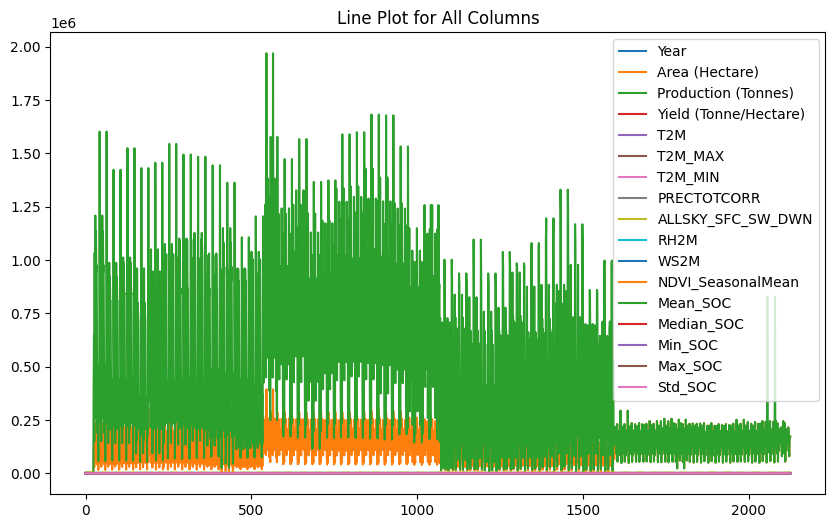

In [16]:
import matplotlib.pyplot as plt

data.plot(figsize=(10, 6))
plt.title("Line Plot for All Columns")
plt.show()


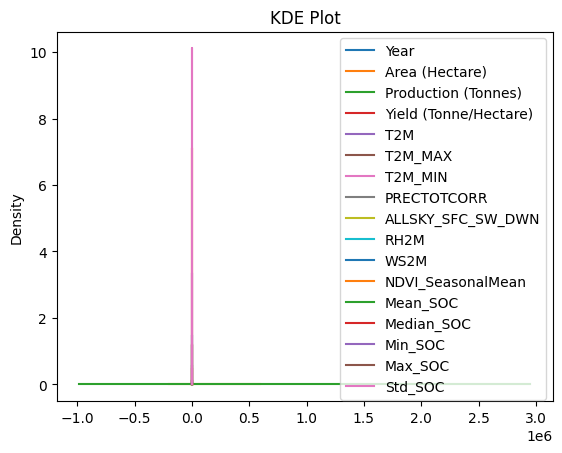

In [12]:
import matplotlib.pyplot as plt

data.plot.kde()
plt.title("KDE Plot")
plt.show()


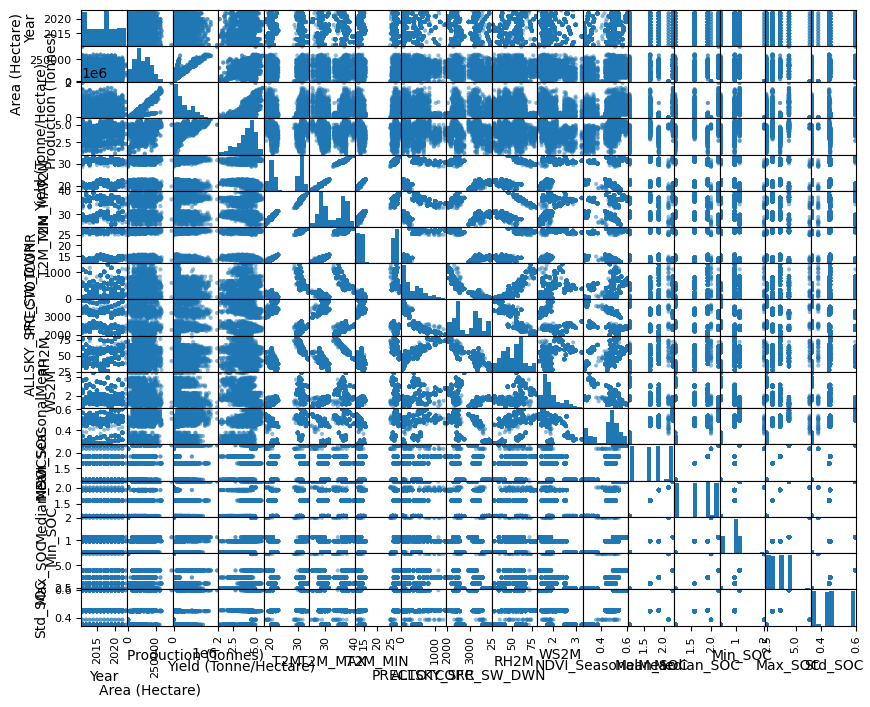

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

pd.plotting.scatter_matrix(data, figsize=(10, 8))
plt.show()
